# Классификация твитов: реальная катастрофа или нет
Проект по NLP (Kaggle «Getting Started»). Цель — предсказать `target` (1 = реальная катастрофа, 0 = нет).

План из 10 этапов реализован в виде модулей в `scripts/` и конфигурации в `configs/default.yaml`.

## Этап 0: Окружение и загрузка данных

In [8]:
import os
from sklearn.metrics import f1_score

os.chdir(os.path.abspath('..'))  # подняться из notebooks/ в корень

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

from scripts.config import load_config
from scripts.data_loader import prepare_data

cfg = load_config('configs/default.yaml')
trn, tst, sample_submission = prepare_data(cfg)
print('trn:', trn.shape, '| tst:', tst.shape)
trn.head()

trn: (7613, 5) | tst: (3263, 4)


,id,keyword,location,text,target
0,1,nones,nones,Our Deeds are the Reason of this #earthquake M...,1
1,4,nones,nones,Forest fire near La Ronge Sask. Canada,1
2,5,nones,nones,All residents asked to 'shelter in place' are ...,1
3,6,nones,nones,"13,000 people receive #wildfires evacuation or...",1
4,7,nones,nones,Just got sent this photo from Ruby #Alaska as ...,1


## Этап 1: EDA

{'class_balance': target
0    4342
1    3271
Name: count, dtype: int64, 'missing_keyword_trn': np.float64(0.0), 'missing_keyword_tst': np.float64(0.0), 'missing_location_trn': np.float64(0.0), 'missing_location_tst': np.float64(0.0), 'keyword_cutoff_coverage': 0.04557992906869828}


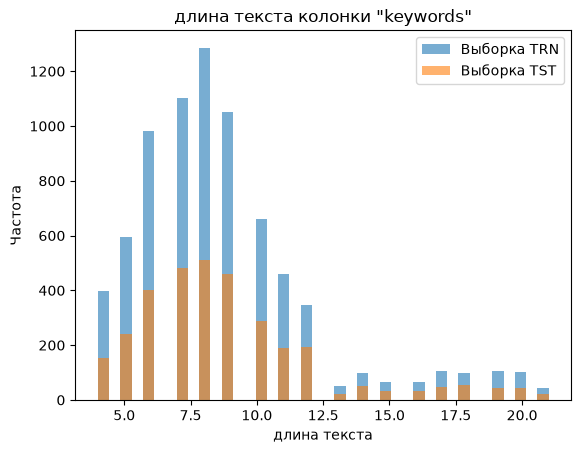

In [3]:
from scripts.eda import run_eda, plot_keyword_length
import matplotlib.pyplot as plt

info = run_eda(trn, tst, cfg)
print(info)
plot_keyword_length(trn, tst, cfg)
plt.show()

## Этап 2: Предобработка текста

In [4]:
from scripts.preprocess import preprocess_dataframe

trn = preprocess_dataframe(trn, cfg)
tst = preprocess_dataframe(tst, cfg)
trn[['text', 'clean_text']].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deed are the reason of thi earthquak may a...
1,Forest fire near La Ronge Sask. Canada,forest fire near la rong sask canada
2,All residents asked to 'shelter in place' are ...,all resid ask to 'shelter in place are be noti...
3,"13,000 people receive #wildfires evacuation or...",peopl receiv wildfir evacu order in california
4,Just got sent this photo from Ruby #Alaska as ...,just got sent thi photo from rubi alaska as sm...


## Этап 3: Инженерия признаков

In [5]:
from scripts.features import add_text_features

trn = add_text_features(trn, cfg)
tst = add_text_features(tst, cfg)
numeric_cols = ['n_words', 'n_unique_words', 'n_upper', 'n_exclam', 'n_question', 'has_keyword']
trn[numeric_cols].head()

,n_words,n_unique_words,n_upper,n_exclam,n_question,has_keyword
0,13,13,10,0,0,0
1,7,7,5,0,0,0
2,22,20,2,0,0,0
3,8,8,1,0,0,0
4,16,15,3,0,0,0


## Этапы 4-6: Сплит, векторизация, обучение

In [6]:
from scripts.train import split_train_val, train_all
from scripts.vectorize import vectorize

trn_split, val = split_train_val(trn, cfg)
X_trn, X_val, pre = vectorize(trn_split, val, cfg, numeric_cols)
y_trn = trn_split[cfg.target_col]
y_val = val[cfg.target_col]

models = train_all(X_trn, y_trn, cfg)
print('Обучены:', list(models.keys()))

Обучены: ['logreg']


## Этапы 7-8: Оценка и анализ ошибок

In [9]:
from scripts.evaluate import evaluate_model, error_analysis

metrics = {}
for name, m in models.items():
    metrics[name] = evaluate_model(m, X_val, y_val)
    print(name, 'F1:', round(metrics[name]['f1'], 4))


logreg F1: 0.7608


## Этап 9: Submission

In [39]:
from scripts.predict import generate_submission, save_submission

best_model = models[max(metrics, key=lambda k: metrics[k]['f1'])]
_, X_tst, pre = vectorize(trn, tst, cfg, numeric_cols)  # refit на всём trn
sub = generate_submission(best_model, X_tst, sample_submission, cfg)
save_submission(sub, cfg)

Submission сохранён: data\submission.csv


## Этап 10: Сводная таблица

In [40]:
from scripts.report import build_summary
summary = build_summary(metrics)
summary

,model,f1,roc_auc,precision_1,recall_1
0,logreg,0.76082,0.870341,0.755656,0.766055


### BERT (этап 2, набросок из оригинала)
Ниже — заготовка `Dataset` для PyTorch/Transformers. Не запускается без `torch` и `transformers`.

In [41]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained(cfg.bert_model_name)

class TextDataset:
    def __init__(self, texts, labels, tokenizer, max_len=cfg.bert_max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], add_special_tokens=True,
                            truncation=True, max_length=self.max_len,
                            padding='max_length', return_attention_mask=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': self.labels[idx]}


c:\Users\User\Desktop\work_dir\Study DS\homeworks\HW_nlp_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# === Продолжение BERT-наброска (опционально, требует torch + transformers) ===
# Модель для классификации
from transformers import BertForSequenceClassification
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BertForSequenceClassification.from_pretrained(cfg.bert_model_name, num_labels=2)
model.to(device)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4551.57it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [13]:

# Подготовка данных (используем TextDataset из ячейки выше)
train_texts = trn_split['clean_text'].tolist()
train_labels = trn_split[cfg.target_col].tolist()
val_texts = val['clean_text'].tolist()
val_labels = val[cfg.target_col].tolist()

train_ds = TextDataset(train_texts, train_labels, tokenizer, max_len=cfg.bert_max_len)
val_ds = TextDataset(val_texts, val_labels, tokenizer, max_len=cfg.bert_max_len)
train_dl = DataLoader(train_ds, batch_size=cfg.bert_batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=cfg.bert_batch_size)

# Оптимизатор
opt = AdamW(model.parameters(), lr=cfg.bert_lr)

# Цикл обучения (упрощённый)
for epoch in range(5):
    model.train()
    tot_loss = 0
    for batch in train_dl:
        opt.zero_grad()
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        lbl = batch['labels'].to(device)
        out = model(**inp, labels=lbl)
        loss = out.loss
        loss.backward()
        opt.step()
        tot_loss += loss.item()
    print(f'epoch {epoch+1}, loss {tot_loss/len(train_dl):.4f}')

# Предсказание на валидации
model.eval()
preds, true = [], []
with torch.no_grad():
    for batch in val_dl:
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**inp).logits
        preds += logits.argmax(dim=1).cpu().tolist()
        true += batch['labels'].tolist()

from sklearn.metrics import classification_report
print(classification_report(true, preds))


epoch 1, loss 0.4990
epoch 2, loss 0.3687
epoch 3, loss 0.2614
epoch 4, loss 0.1769
epoch 5, loss 0.1298
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       869
           1       0.77      0.77      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



Дообучаю 

In [15]:
# Цикл обучения (упрощённый)
for epoch in range(10):
    model.train()
    tot_loss = 0
    for batch in train_dl:
        opt.zero_grad()
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        lbl = batch['labels'].to(device)
        out = model(**inp, labels=lbl)
        loss = out.loss
        loss.backward()
        opt.step()
        tot_loss += loss.item()
    print(f'epoch {epoch+1}, loss {tot_loss/len(train_dl):.4f}')

epoch 1, loss 0.1028
epoch 2, loss 0.0900
epoch 3, loss 0.0750
epoch 4, loss 0.0737
epoch 5, loss 0.0739
epoch 6, loss 0.0666
epoch 7, loss 0.0742
epoch 8, loss 0.0636
epoch 9, loss 0.0596
epoch 10, loss 0.0507


In [16]:
# Предсказание вероятностей на валидации
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score

model.eval()
probs, true = [], []
with torch.no_grad():
    for batch in val_dl:
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**inp).logits
        # softmax по dim=1 -> вероятности классов [p0, p1]
        batch_probs = F.softmax(logits, dim=1)
        probs += batch_probs.cpu().tolist()           # список списков [[p0,p1], ...]
        true += batch['labels'].tolist()

# вероятность класса 1 (катастрофа)
probs_1 = [p[1] for p in probs]

print(classification_report(true, [1 if p[1] >= 0.5 else 0 for p in probs]))
print("ROC-AUC:", roc_auc_score(true, probs_1))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       869
           1       0.79      0.77      0.78       654

    accuracy                           0.82      1523
   macro avg       0.81      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523

ROC-AUC: 0.851374035324796


In [34]:
f1_score(true, [1 if p[1] >= 0.5 else 0 for p in probs])

0.7829457364341085